In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data into df
df = pd.read_csv("weekly_top10_centroids.csv")

df.head()

,date,tempo,loudness,key,mode,count
0,1958-08-04,108.974,-12.808,4.0,1.0,1
1,1983-12-03,86.693,-5.030,7.0,1.0,1
2,1983-12-10,86.693,-5.030,7.0,1.0,1
3,1984-01-07,85.207,-14.361,9.0,0.0,1
4,1984-01-14,85.207,-14.361,9.0,0.0,1


In [50]:
# Sort and make week datetime
df['week'] = pd.to_datetime(df['date'])
df = df.sort_values('week')

df

,date,tempo,loudness,key,mode,count,week
0,1958-08-04,108.974,-12.8080,4.0,1.0,1,1958-08-04
619,1958-08-11,108.974,-12.8080,4.0,1.0,1,1958-08-11
620,1958-08-18,108.974,-12.8080,4.0,1.0,1,1958-08-18
621,1958-08-25,108.974,-12.8080,4.0,1.0,1,1958-08-25
622,1958-09-01,108.974,-12.8080,4.0,1.0,1,1958-09-01
...,...,...,...,...,...,...,...
1184,2010-06-19,101.520,-5.6865,6.5,1.0,2,2010-06-19
338,2011-07-16,139.990,-3.9240,8.0,1.0,1,2011-07-16
339,2016-01-30,137.068,-12.6790,0.0,1.0,1,2016-01-30
386,2021-01-02,92.980,-9.6470,5.0,1.0,1,2021-01-02


In [51]:
# Create aggregations
monthly = (
    df.set_index('week')
      .resample('ME')
      .mean(numeric_only=True)
      .reset_index()
)
# Drop months where count average < 1.5
monthly = monthly[monthly['count'] > 1.5]


quarterly = (
    df.set_index('week')
      .resample('QE')
      .mean(numeric_only=True)
      .reset_index()
)
# Drop quarters where count average < 1.5
quarterly = quarterly[quarterly['count'] > 1.5]

yearly = (
    df.set_index('week')
      .resample('YE')
      .mean(numeric_only=True)
      .reset_index()
)
# Drop years where count average < 1.5
yearly = yearly[yearly['count'] > 1.5]
print(yearly)

         week       tempo   loudness       key      mode     count
1  1959-12-31  137.225519 -11.367083  6.673932  1.000000  2.256410
2  1960-12-31   98.903750 -13.780645  6.723684  1.000000  1.631579
3  1961-12-31   90.700272 -14.448035  7.491870  1.000000  1.902439
4  1962-12-31  128.421103 -11.460256  3.602963  1.000000  2.044444
5  1963-12-31  111.810886  -9.594720  5.442188  1.000000  3.187500
7  1965-12-31  113.882405 -10.313179  6.071429  0.702381  1.547619
11 1969-12-31  130.057042 -11.151161  7.494792  0.744792  1.875000
14 1972-12-31  139.451346  -9.824568  5.500000  0.827778  1.812500
15 1973-12-31  131.611014 -10.881292  5.625000  0.680556  1.638889
17 1975-12-31  129.378719 -10.511625  5.250000  0.937500  1.562500
24 1982-12-31  119.681723 -10.517955  7.178571  0.633929  1.607143
25 1983-12-31  116.631479  -8.693234  8.063830  0.882979  1.978723
26 1984-12-31  131.296966 -10.086879  5.925170  0.683673  1.857143
27 1985-12-31  120.199124  -8.301849  2.779570  0.913978  1.74

In [52]:
# Check total counts per year
yearly_counts = (
    df.set_index('week')
      .resample('YE')['count']
      .sum()
)


pd.set_option('display.max_rows', None)
print(yearly_counts)
pd.reset_option('display.max_rows')

week
1958-12-31      8
1959-12-31     88
1960-12-31     31
1961-12-31     78
1962-12-31     92
1963-12-31    102
1964-12-31     54
1965-12-31     65
1966-12-31     18
1967-12-31     45
1968-12-31     34
1969-12-31     60
1970-12-31     20
1971-12-31     24
1972-12-31     87
1973-12-31     59
1974-12-31      3
1975-12-31     50
1976-12-31     17
1977-12-31      8
1978-12-31     14
1979-12-31     11
1980-12-31     27
1981-12-31     76
1982-12-31     45
1983-12-31     93
1984-12-31     91
1985-12-31     54
1986-12-31     86
1987-12-31     26
1988-12-31    145
1989-12-31     52
1990-12-31     77
1991-12-31     97
1992-12-31     45
1993-12-31    150
1994-12-31    247
1995-12-31    134
1996-12-31    133
1997-12-31    105
1998-12-31     55
1999-12-31     35
2000-12-31    107
2001-12-31    189
2002-12-31     68
2003-12-31     88
2004-12-31    313
2005-12-31    294
2006-12-31    214
2007-12-31    131
2008-12-31    184
2009-12-31    157
2010-12-31     35
2011-12-31      1
2012-12-31      0
2013-

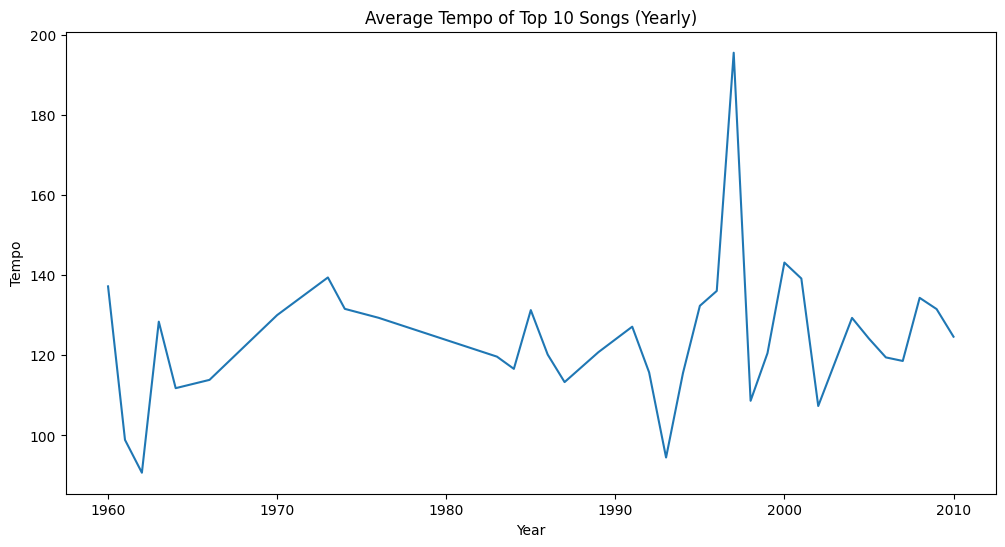

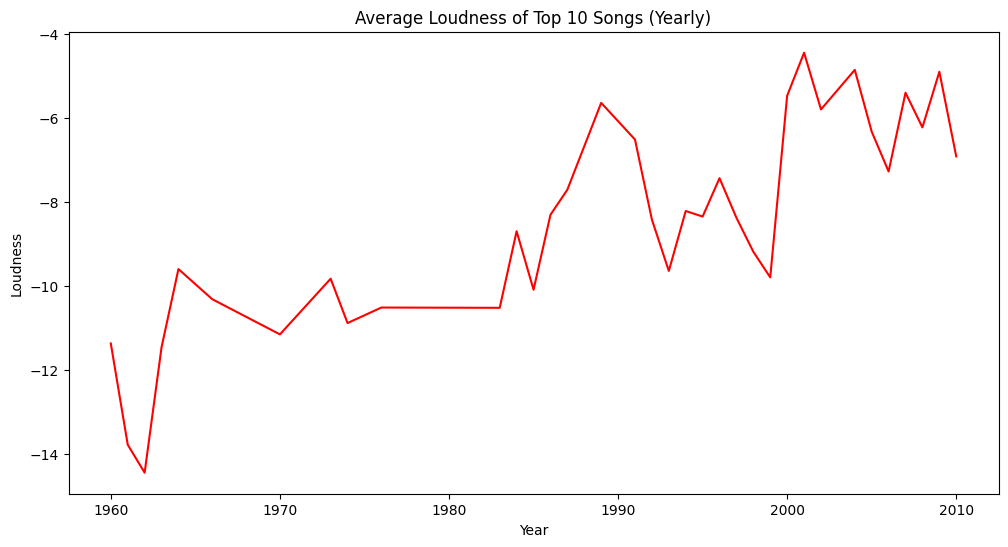

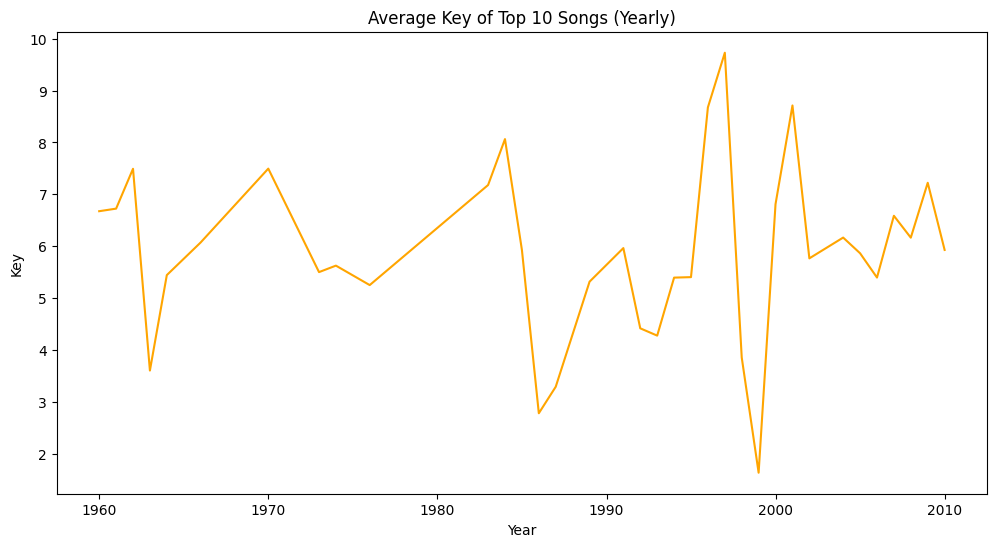

In [53]:
# Plot over time
plt.figure(figsize=(12,6))
plt.plot(yearly['week'], yearly['tempo'])
plt.title("Average Tempo of Top 10 Songs (Yearly)")
plt.xlabel("Year")
plt.ylabel("Tempo")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(yearly['week'], yearly['loudness'], color='red')
plt.title("Average Loudness of Top 10 Songs (Yearly)")
plt.xlabel("Year")
plt.ylabel("Loudness")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(yearly['week'], yearly['key'], color='orange')
plt.title("Average Key of Top 10 Songs (Yearly)")
plt.xlabel("Year")
plt.ylabel("Key")
plt.show()

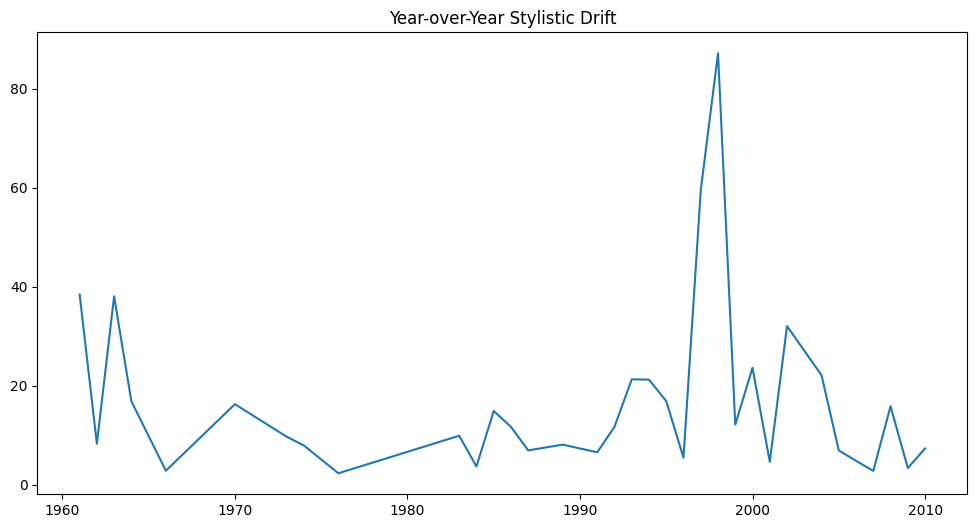

In [54]:
# Compute magnitude of drift over time
features = yearly.columns.drop('week')

drift = []

for i in range(1, len(yearly)):
    diff = np.linalg.norm(
        yearly[features].iloc[i] - yearly[features].iloc[i-1]
    )
    drift.append(diff)

yearly_drift = yearly.iloc[1:].copy()
yearly_drift['drift'] = drift

plt.figure(figsize=(12,6))
plt.plot(yearly_drift['week'], yearly_drift['drift'])
plt.title("Year-over-Year Stylistic Drift")
plt.show()

In [56]:
# Decide best aggregation level
def compute_drift(data):
    features = data.columns.drop('week')
    drift = []
    for i in range(1, len(data)):
        diff = np.linalg.norm(
            data[features].iloc[i] - data[features].iloc[i-1]
        )
        drift.append(diff)
    return np.mean(drift)

print("Monthly drift:", compute_drift(monthly))
print("Quarterly drift:", compute_drift(quarterly))
print("Yearly drift:", compute_drift(yearly))

Monthly drift: 10.632057426021076
Quarterly drift: 16.88463428169712
Yearly drift: 16.4986796800476
